# CartPole DQN의 통계적 보상 함수 설계 실험

개선된 모델에서 패널티를 부과하여 통계학적 보상을 설계 하는 실습

기존 DQN에서 reward를 직접 수정해서, 단순히 오래 버티는 것뿐만 아니라 막대 각도와 각속도의 변동성을 줄이도록 학습시키려는 실험

1. num_episodes = 500
2. epsilon_decay = 0.99
3. learning rate = 0.0005
4. 초기 Replay Buffer 경험 1000개 저장
5. target_net은 10 에피소드마다 업데이트

In [1]:
# 라이브러리 불러오기
import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym

In [2]:
# device 설정
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("사용 device:", device)

사용 device: mps


In [3]:
# CartPole 환경 생성
env = gym.make("CartPole-v1")

state, info = env.reset(seed=42)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print("state_dim:", state_dim)
print("action_dim:", action_dim)

state_dim: 4
action_dim: 2


In [4]:
# DQN 모델 정의
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

In [5]:
# Replay Buffer 구현
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(np.array(states), dtype=torch.float32).to(device)
        actions = torch.tensor(actions, dtype=torch.long).unsqueeze(1).to(device)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(device)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32).to(device)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(device)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

In [6]:
# 모델, 손실 함수, 옵티마이저 설정
policy_net = DQN(state_dim, action_dim).to(device)

target_net = DQN(state_dim, action_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

criterion = nn.MSELoss()
optimizer = optim.Adam(policy_net.parameters(), lr=0.0005)

replay_buffer = ReplayBuffer(capacity=10000)

gamma = 0.99
batch_size = 64

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.99

num_episodes = 500
target_update = 10

print(policy_net)

DQN(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [7]:
# epsilon-greedy 행동 선택 함수
def select_action(state, epsilon):
    if random.random() < epsilon:
        action = env.action_space.sample()
    else:
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            q_values = policy_net(state_tensor)

        action = q_values.argmax(dim=1).item()

    return action

In [8]:
# 초기 랜덤 경험 1000개 저장
state, info = env.reset(seed=42)

for step in range(1000):
    action = env.action_space.sample()

    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    replay_buffer.push(state, action, reward, next_state, done)

    state = next_state

    if done:
        state, info = env.reset()

print("초기 Replay Buffer 크기:", len(replay_buffer))

초기 Replay Buffer 크기: 1000


In [9]:
# DQN 학습 함수
def train_step():
    if len(replay_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    current_q_values = policy_net(states).gather(1, actions)

    with torch.no_grad():
        next_q_values = target_net(next_states).max(dim=1, keepdim=True)[0]
        target_q_values = rewards + gamma * next_q_values * (1 - dones)

    loss = criterion(current_q_values, target_q_values)

    optimizer.zero_grad()
    loss.backward()

    # 기울기가 너무 커지는 것을 방지
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=1.0)

    optimizer.step()

    return loss.item()

In [10]:
# 수정할 셀: # DQN 학습 루프
import numpy as np
import os

episode_rewards = []
episode_steps = []       # 실제 버틴 스텝 수 기록 (정량 지표)
all_episode_angles = []  # 각 에피소드별 막대 각도의 분산을 기록 (질적 지표)
losses = []
best_avg_reward = -float("inf")

for episode in range(num_episodes):
    state, info = env.reset()
    total_reward = 0
    step_count = 0
    episode_angles = []  # 이번 에피소드에서 발생하는 모든 각도를 수집
    done = False

    while not done:
        action = select_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # 현재 스텝의 막대 각도(next_state[2])를 리스트에 추가
        episode_angles.append(next_state[2])

        # ==================================================================
        # [3단계: 통계학적 변동성 페널티 설계]
        # next_state[2]: 막대 각도(theta), next_state[3]: 막대 각속도(theta_dot)

        angle_penalty = next_state[2] ** 2
        velocity_penalty = next_state[3] ** 2

        # 기본 보상 1.0에서 자승 오차 기반 감점 적용
        modified_reward = 1.0 - (angle_penalty + 0.1 * velocity_penalty)

        # Replay Buffer에는 수정된 보상을 저장
        replay_buffer.push(state, action, modified_reward, next_state, done)

        loss = train_step()

        if loss is not None:
            losses.append(loss)

        state = next_state
        total_reward += modified_reward
        step_count += 1

    episode_rewards.append(total_reward)
    episode_steps.append(step_count)

    # 이번 에피소드 전체 각도 데이터의 '표본 분산'을 계산하여 저장
    all_episode_angles.append(np.var(episode_angles))

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (episode + 1) % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if (episode + 1) % 10 == 0:
        recent_avg_reward = np.mean(episode_rewards[-10:])
        recent_avg_step = np.mean(episode_steps[-10:])
        recent_avg_variance = np.mean(all_episode_angles[-10:])  # 최근 10회 평균 흔들림 분산

        if recent_avg_reward > best_avg_reward:
            best_avg_reward = recent_avg_reward
            # 상위 폴더의 models/ 폴더가 없다면 자동 생성 후 저장
            os.makedirs("../models", exist_ok=True)
            torch.save(policy_net.state_dict(), "../models/statistical_best.pt")

        print(
            f"Episode {episode + 1}, "
            f"Avg Reward: {recent_avg_reward:.2f}, "
            f"Avg Survival Step: {recent_avg_step:.2f}, "
            f"Avg Angle Variance: {recent_avg_variance:.6f}, "  # 통계적 수치 모니터링
            f"Epsilon: {epsilon:.4f}"
        )

Episode 10, Avg Reward: 17.14, Avg Survival Step: 19.00, Avg Angle Variance: 0.005167, Epsilon: 0.9044
Episode 20, Avg Reward: 16.78, Avg Survival Step: 18.60, Avg Angle Variance: 0.004544, Epsilon: 0.8179
Episode 30, Avg Reward: 42.45, Avg Survival Step: 44.40, Avg Angle Variance: 0.006001, Epsilon: 0.7397
Episode 40, Avg Reward: 35.95, Avg Survival Step: 37.80, Avg Angle Variance: 0.004993, Epsilon: 0.6690
Episode 50, Avg Reward: 51.32, Avg Survival Step: 54.40, Avg Angle Variance: 0.006243, Epsilon: 0.6050
Episode 60, Avg Reward: 72.08, Avg Survival Step: 75.60, Avg Angle Variance: 0.007044, Epsilon: 0.5472
Episode 70, Avg Reward: 75.78, Avg Survival Step: 79.20, Avg Angle Variance: 0.005406, Epsilon: 0.4948
Episode 80, Avg Reward: 116.80, Avg Survival Step: 121.40, Avg Angle Variance: 0.007129, Epsilon: 0.4475
Episode 90, Avg Reward: 282.41, Avg Survival Step: 288.70, Avg Angle Variance: 0.002582, Epsilon: 0.4047
Episode 100, Avg Reward: 86.18, Avg Survival Step: 89.40, Avg Angle V

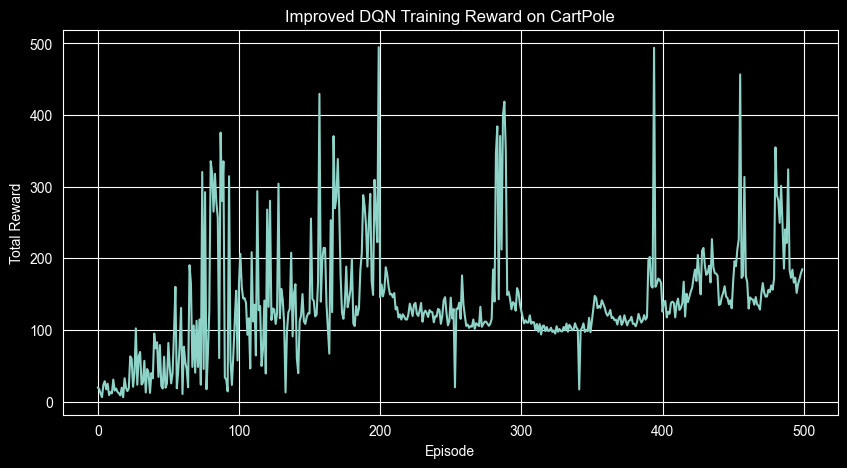

In [11]:
# 에피소드별 누적 보상 그래프
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Improved DQN Training Reward on CartPole")
plt.show()

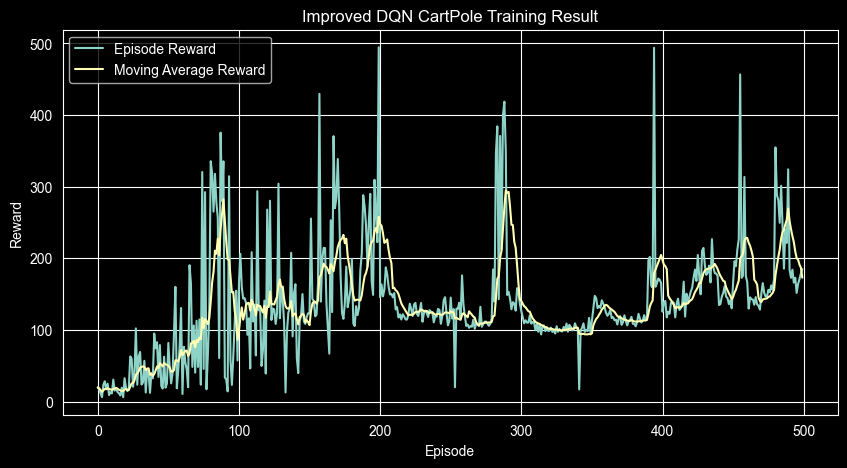

In [12]:
# 최근 10개 에피소드 평균 보상 그래프
moving_avg = []

for i in range(len(episode_rewards)):
    recent_rewards = episode_rewards[max(0, i - 9):i + 1]
    moving_avg.append(np.mean(recent_rewards))

plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, label="Episode Reward")
plt.plot(moving_avg, label="Moving Average Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Improved DQN CartPole Training Result")
plt.legend()
plt.show()

In [13]:
# 학습 후 최종 결과 확인
print("마지막 10개 에피소드 평균 보상:", np.mean(episode_rewards[-10:]))
print("최고 에피소드 보상:", max(episode_rewards))
print("최종 epsilon:", epsilon)
print("최종 Replay Buffer 크기:", len(replay_buffer))

마지막 10개 에피소드 평균 보상: 173.05647
최고 에피소드 보상: 494.54752
최종 epsilon: 0.05
최종 Replay Buffer 크기: 10000


1. 같은 구조의 DQN 모델을 새로 만든다.
2. 저장된 가중치 improved_dqn_cartpole.pt를 불러온다.
3. 모델을 eval 모드로 바꾼다.
4. epsilon 없이 Q-value가 가장 큰 행동만 선택해서 테스트한다.
5. 여러 에피소드의 평균 보상을 확인한다.

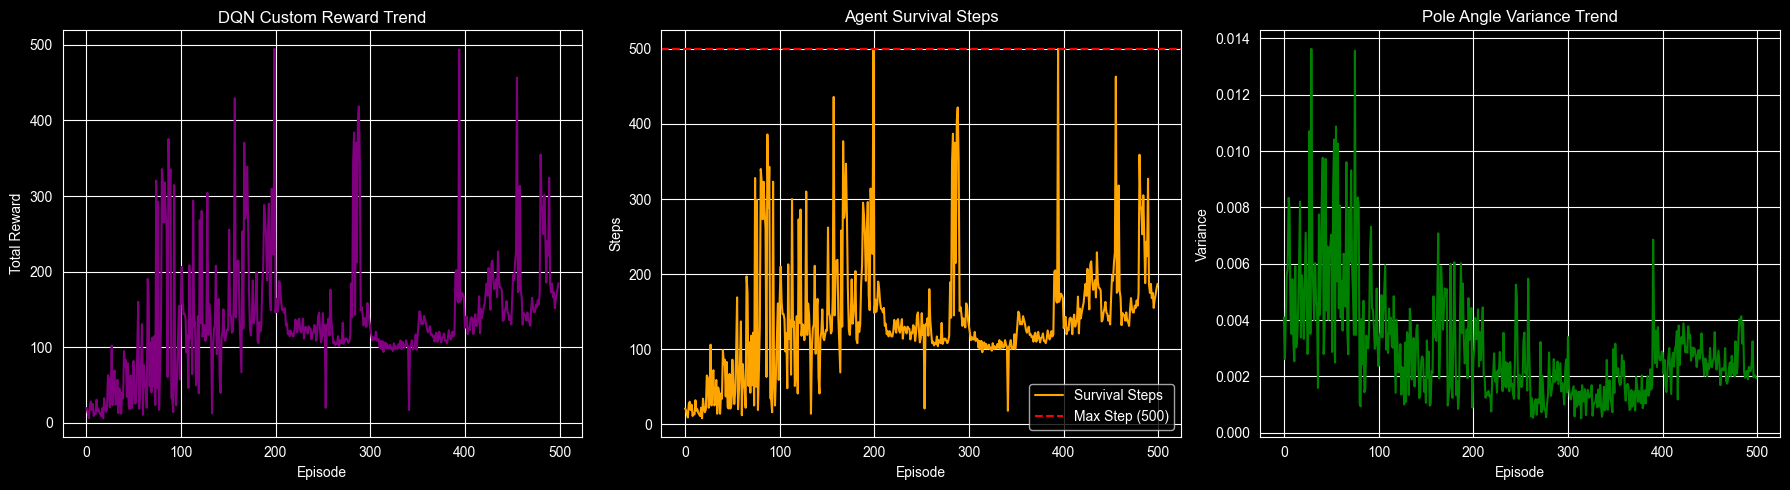

In [16]:
# 수정할 셀: # 학습 결과 시각화
plt.figure(figsize=(18, 5))

# 1. 누적 보상 그래프 (감점 반영 세팅)
plt.subplot(1, 3, 1)
plt.plot(episode_rewards, label='Modified Reward', color='purple')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('DQN Custom Reward Trend')
plt.grid(True)

# 2. 실제 버틴 스텝 그래프 (정량적 만점 수렴 증명)
plt.subplot(1, 3, 2)
plt.plot(episode_steps, label='Survival Steps', color='orange')
plt.axhline(y=500, color='r', linestyle='--', label='Max Step (500)')
plt.xlabel('Episode')
plt.ylabel('Steps')
plt.title('Agent Survival Steps')
plt.legend()
plt.grid(True)

# 3. 막대 각도의 분산 변화 그래프 (질적 고도화의 핵심 증거)
plt.subplot(1, 3, 3)
plt.plot(all_episode_angles, label='Angle Variance', color='green')
plt.xlabel('Episode')
plt.ylabel('Variance')
plt.title('Pole Angle Variance Trend')
plt.grid(True)

plt.tight_layout()
plt.show()